# Bias-Variance Tradeoff

### Objective

This notebook demonstrates bias-variance tradeoff using synthetic healthcare dataset.

The dataset represents patients' age and their systolic blood pressure. The relationship contains some natural variation, allowing us to compare models of different complexity.

### Key Ideas

- **High Bias:** model is too simple and underfits.
- **High Variance:** model is too complex and overfits.
- **Ideal Model:** balances complexity and generalisation to achieve low bias and low variance.

## 01. Dataset
### 1.1 Generate Dataset

In [ ]:
#import modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
print("Modules imported")

#random number generator from numpy to create reproducible noise
np.random.seed(42)
#create 30 ages evenly (linearly) spaced between 20 to 80.
age = np.linspace(20, 80, 30)

#Synthetic systolic blood pressure with nonlinear r/s
blood_pressure = (100 + 0.4*age + 0.015 * (age-50)**2 + np.random.normal(0, 5, 30))

#Generate data into df of age and systolic bp
df = pd.DataFrame({'age': age, 'systolic_bp': blood_pressure})
df.head()

Modules imported


,age,systolic_bp
0,20.000000,123.983571
1,22.068966,119.838405
2,24.137931,122.926314
3,26.206897,126.589584
4,28.275862,117.218650


### 1.2 Explore Dataset

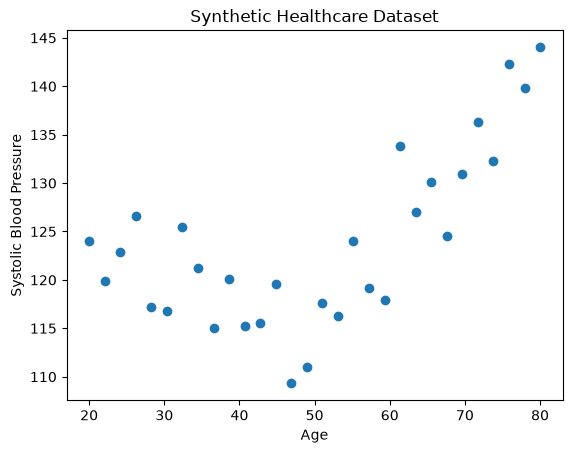

In [5]:
plt.scatter(df['age'], df['systolic_bp'])
plt.xlabel('Age')
plt.ylabel('Systolic Blood Pressure')
plt.title('Synthetic Healthcare Dataset')
plt.show()

### 1.3 Train/Test Split

The dataset is split into training and testing sets. The training set is used to fit the model while the testing set is used to evaluate how well the model perform to unseen data.

In [ ]:
#import module
from sklearn.model_selection import train_test_split

#X = predictor (age), y = target (systolic bp)
X = df[['age']]
y = df['systolic_bp']

#Split X and y into test data (30%) and train data (70%), using this particular (42) random split every time for reproduciblility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))

Training samples: 21
Test samples: 9


## 02. Models of Different Complexity
### 2.1 Fit Models of Different Complexity

Polynomial regression allows us to increase model complexity by increasing the degree of polynomial.

We compare degree 1, 2, and 5 models to demonstrate overfitting and underfitting.

Models fitted.


/Users/hweeenheah/Downloads/EDA_Resources/machine-learning-foundations/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/Users/hweeenheah/Downloads/EDA_Resources/machine-learning-foundations/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/Users/hweeenheah/Downloads/EDA_Resources/machine-learning-foundations/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


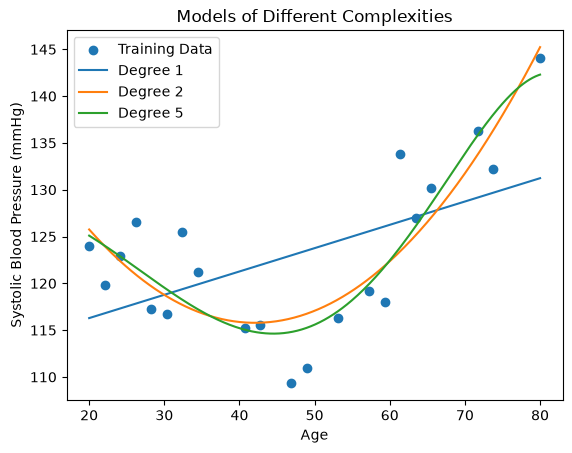

In [19]:
#import modules
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

#Initial polynomial degree and models dictionary
degrees = [1, 2, 5]
models = {}

#Fit models
for degree in degrees:
    #take age and give it polynomial terms, then use linear reg to fit coefficients to the polynomial terms
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    #use training data to find best coefficients for this polynomial model
    model.fit(X_train, y_train)
    #store model into models dictionary with its corresponding degree
    models[degree] = model
print("Models fitted.")    

#Creating curves to plot
#Create 300 evenly spaces ages between 20 to 80 (300 for smooth-looking curve)
X_plot = np.linspace(20, 80, 300).reshape(-1, 1)
#Plot training dataset
plt.scatter(X_train, y_train, label='Training Data')
#Plot 3 models of degrees 1, 2, and 10
for degree, model in models.items():
    #y_plot contains 300 predicted bp values
    y_plot = model.predict(X_plot)
    plt.plot(X_plot, y_plot, label=f'Degree {degree}')

plt.xlabel('Age')
plt.ylabel('Systolic Blood Pressure (mmHg)')
plt.title('Models of Different Complexities')
plt.legend()
plt.show()

### 2.2 Compare Training and Testing Errors

A model can perform well on the training data but poorly on unseen (test) data. We compare training and testing error to identify underfitting or overfitting.

We will use Mean Squared Error (MSE), where lower MSE means better predictions.

In [20]:
from sklearn.metrics import mean_squared_error

results = []

#for each model, make predictions on training data, then on test data
for degree, model in models.items():
    train_predictions = model.predict(X_train)
    test_predictions = model.predict(X_test)

    #calculate training mse (how well it fit?), then test mse (how well it generalise?)
    train_mse = mean_squared_error(y_train, train_predictions)
    test_mse = mean_squared_error(y_test, test_predictions)

    #store results
    results.append({'Degree': degree, 'Training MSE': train_mse, 'Test MSE': test_mse})

results_df = pd.DataFrame(results)
print(results_df)    

   Degree  Training MSE   Test MSE
0       1     52.326876  36.424304
1       2     18.576512   9.973559
2       5     15.878487  15.221619


## 03. Results & Conclusion

A model with high bias/underfitting has relatively high training and test error. A model with high variance/overfitting has very low training error and a much higher test error. A good model balances low training error with low test error. It should not simply fit the training data well, it should also perform reasonably well against unseen test data. 

The degree 1 model showed the highest training and test errors, suggesting underfitting and high bias. 

The degree 2 model showed a good balance between training and test errors, demonstrating a good model fit. 

The degree 5 model showed a small reduction in training error but an increase in test error. It fits the training data better, but its test performance worsens, showing the beginning of high variance/overfitting. 